# B12.4 Stability and Potential Energy
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B12.4.1 Motivation

The concept of **stability** lies at the core of all physical systems — it tells us whether a system will return to equilibrium after a small disturbance, or diverge away into new motion. By examining how **potential energy varies with position**, we can determine the *behavior near equilibrium* without solving the equations of motion directly.

The **graph of potential energy**, $U(x)$, is a powerful visual tool. It reveals at a glance whether equilibrium points are **stable**, **unstable**, or **neutral**, and provides a direct connection between **force**, **energy**, and **motion**.  
This same analysis helps us understand:

- **Planetary motion:** why bound orbits (elliptical) correspond to potential wells and unbound orbits (hyperbolic) correspond to escape energies.  
- **Engineering systems:** how bridges, buildings, or suspension systems respond to small oscillations or large perturbations.  
- **Chemistry:** how atoms vibrate about equilibrium positions in molecular bonds.  
- **Biology and physiology:** how the body maintains balance, and how biological rhythms return to homeostasis after small deviations.

In essence, stability analysis is the universal lens through which we understand equilibrium and motion — from molecular vibrations to galactic dynamics.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B12.4.2 Taylor Expansion of the Potential Energy

Near any equilibrium position $x_0$, we can approximate a smooth potential energy function using a **Taylor expansion**:

$$
U(x) = U(x_0) + \left.\frac{dU}{dx}\right|_{x_0}(x - x_0) + \frac{1}{2}\left.\frac{d^2U}{dx^2}\right|_{x_0}(x - x_0)^2 + \cdots
$$

At equilibrium, the **net force is zero** (or the slope of the potential energy vs. position is zero), so

$$
\left.\frac{dU}{dx}\right|_{x_0} = 0.
$$

Thus, near $x_0$ we have:

$$
U(x) \approx U(x_0) + \frac{1}{2}k_{\text{eff}}(x - x_0)^2,
$$

where  

$$
k_{\text{eff}} = \left.\frac{d^2U}{dx^2}\right|_{x_0}
$$

is the **effective stiffness** or **curvature** of the potential well.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B12.4.3 Stability Criteria

- **Stable equilibrium:** $k_{\text{eff}} > 0$, or $\dfrac{d^2U}{dx^2} > 0$.  
  The potential has a **minimum**; the system oscillates about $x_0$.

- **Unstable equilibrium:** $k_{\text{eff}} < 0$, or $\dfrac{d^2U}{dx^2} < 0$.  
  The potential has a **maximum**; small displacements grow over time.

- **Neutral equilibrium:** $k_{\text{eff}} = 0$.  
  The potential is **flat** near $x_0$, and the system experiences no restoring force.

These correspond to what we call **fixed points** — positions where the force (the slope of $U$) is zero.  
Whether a fixed point is stable or unstable depends on the *curvature* of $U$ at that point.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B12.4.4Turning Points and Motion in a Potential

When total mechanical energy is conserved,

$$
E = K + U(x),
$$

the **kinetic energy** is

$$
K = E - U(x) = \tfrac{1}{2} m v^2.
$$

At points where $E = U(x)$, the velocity $v = 0$.  
These are called **turning points** — the particle reverses direction there.

- For **bound motion**, $E < U_{\text{max}}$, the particle oscillates between two turning points.
- For **unbound motion**, $E > U_{\text{max}}$, it escapes the potential well.

This simple graphical interpretation of $U(x)$ versus $x$ is extremely powerful — it lets us visualize dynamics without solving equations.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B12.4.5 Fixed Points and Phase Space

In one dimension, **fixed points** correspond to locations where both $v=0$ and $F=-\dfrac{dU}{dx}=0$.  
Plotting motion in **phase space** (position vs. velocity) reveals:

- **Stable points:** small closed loops (oscillations).  
- **Unstable points:** diverging trajectories.  
- **Saddle points:** mixed behavior (stable in one direction, unstable in another).

These patterns generalize beautifully to higher-dimensional systems.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B12.4.6 Example

<div style="background-color:#d9d9d9; padding:15px; border-radius:10px;">

**Spring System**

For a spring with potential energy

$$
U(x) = \tfrac{1}{2}k x^2,
$$

the equilibrium is at $x_0 = 0$.  
Then,

$$
\frac{dU}{dx} = kx, \quad \frac{d^2U}{dx^2} = k > 0.
$$

Since $k > 0$, the equilibrium is **stable**, and we recover simple harmonic motion:

$$
m\ddot{x} = -k x.
$$

If instead $U(x) = -\tfrac{1}{2}k x^2$, then $k_{\text{eff}} < 0$ and equilibrium becomes **unstable** — any small displacement grows exponentially rather than oscillating.

</div>

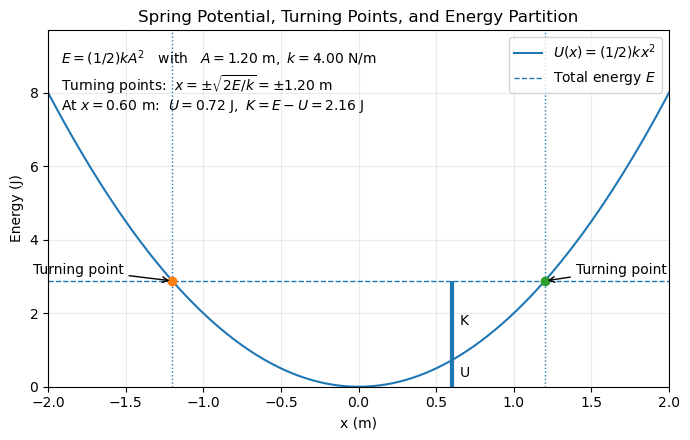

In [13]:
# Spring potential example: U(x) = (1/2) k x^2
# This script plots U vs x, annotates turning points for a chosen total energy E,
# draws a horizontal dashed line at E, and shows vertical segments at an arbitrary
# position x_star to indicate the partition into potential (U) and kinetic (K = E - U).

import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parameters (edit freely)
# -----------------------
m = 1.0          # mass (kg)
k = 4.0          # spring constant (N/m)
A = 1.2          # amplitude corresponding to energy E (m)
x_star = 0.6     # arbitrary position at which to show U and K bars (m)

E = 0.5 * k * A**2          # total mechanical energy (J)

# -------------
# Computations
# -------------
def U(x): 
    return 0.5 * k * x**2

# Turning points solve E = U(x) => x = ±sqrt(2E/k)
x_turn = np.sqrt(2 * E / k)
x1, x2 = -x_turn, x_turn

# Build plotting range that comfortably includes turning points
xmax = max(abs(x1), abs(x2), abs(x_star)) * 1.25 + 0.5
x = np.linspace(-xmax, xmax, 800)
Ux = U(x)

U_star = U(x_star)
K_star = E - U_star  # could be negative if x_star is classically forbidden

# -------------
# Plotting
# -------------
fig, ax = plt.subplots(figsize=(7, 4.5))

# Potential energy curve
ax.plot(x, Ux, label=r"$U(x) = (1/2) k x^2$")

# Total energy horizontal line
ax.axhline(E, linestyle="--", linewidth=1, label="Total energy $E$")

# Turning points as vertical dotted lines with markers
ax.axvline(x1, linestyle=":", linewidth=1)
ax.axvline(x2, linestyle=":", linewidth=1)
ax.plot([x1], [E], marker="o")
ax.plot([x2], [E], marker="o")

# Annotate turning points
ax.annotate("Turning point",
            xy=(x2, E), xytext=(x2 + 0.2, E + 0.2),
            arrowprops=dict(arrowstyle="->", lw=1), fontsize=10)
ax.annotate("Turning point",
            xy=(x1, E), xytext=(x1 - 0.9, E + 0.2),
            arrowprops=dict(arrowstyle="->", lw=1), fontsize=10)

# Vertical bars at x_star to show U and K partition
# Potential (from 0 up to U_star)
ax.vlines(x_star, 0, max(U_star, 0), linewidth=3)
ax.text(x_star + 0.05, U_star/2, "U", va="center", fontsize=10)

# Kinetic (from U_star up to E), only if classically allowed (K_star >= 0)
if K_star >= 0:
    ax.vlines(x_star, U_star, E, linewidth=3)
    ax.text(x_star + 0.05, U_star + K_star/2, "K", va="center", fontsize=10)
else:
    # Indicate forbidden region if E < U(x_star)
    ax.annotate("Classically forbidden\n(E < U)",
                xy=(x_star, U_star), xytext=(x_star + 0.3, U_star + 0.4),
                arrowprops=dict(arrowstyle="->", lw=1), fontsize=10)

# Labels, legend, and aesthetics
ax.set_xlabel("x (m)")
ax.set_ylabel("Energy (J)")
ax.set_title("Spring Potential, Turning Points, and Energy Partition")
ax.legend(loc="upper right")

# Axis limits and grid
ax.set_xlim(-xmax, xmax)
ymax = max(E, Ux.max()) * 1.15 + 0.5
ax.set_ylim(0, ymax)
ax.grid(True, alpha=0.25)

# Helpful inline text
ax.text(0.02, 0.95,
        rf"$E = (1/2) k A^2$   with   $A = {A:.2f}\ \mathrm{{m}},\ k = {k:.2f}\ \mathrm{{N/m}}$",
        transform=ax.transAxes, va="top", fontsize=10)
ax.text(0.02, 0.88,
        rf"Turning points:  $x = \pm\sqrt{{2E/k}} = \pm{abs(x2):.2f}\ \mathrm{{m}}$",
        transform=ax.transAxes, va="top", fontsize=10)
ax.text(0.02, 0.81,
        rf"At $x = {x_star:.2f}\ \mathrm{{m}}$:  $U = {U_star:.2f}\ \mathrm{{J}},\ K = E - U = {K_star:.2f}\ \mathrm{{J}}$",
        transform=ax.transAxes, va="top", fontsize=10)

plt.tight_layout()
plt.show()


<div style="background-color:#d9d9d9; padding:15px; border-radius:10px;">
    
**Interpretation of the $U(x)$ vs. $x$ Plot**

The potential energy curve $U(x) = \tfrac{1}{2} k x^2$ represents a **parabolic potential well** centered at the equilibrium position $x = 0$.  
This shape is characteristic of all systems undergoing **simple harmonic motion** — the curvature of the parabola determines how strongly the system is pulled back toward equilibrium.

The **horizontal dashed line** represents the system’s **total mechanical energy**, $E = \tfrac{1}{2}kA^2$, which remains constant throughout the motion.  
The intersection points of this line with the potential curve mark the **turning points** ($x = \pm A$), where the particle momentarily stops before reversing direction.  
At these points, the energy is entirely **potential**, and the **kinetic energy** is zero.

At any other position $x$ within this range:
- The **potential energy** $U(x)$ is proportional to $x^2$, increasing as the mass moves away from equilibrium.  
- The **kinetic energy** $K = E - U(x)$ fills the remaining portion up to $E$, decreasing as potential energy increases.  
  The vertical bars at $x_*$ in the plot illustrate this continuous **exchange between $U$ and $K$**.

The shape of the curve and the horizontal energy line together provide a **complete graphical picture of the dynamics**:
- Motion is confined between the turning points ($E = U$).  
- The slope of $U(x)$, $F = -dU/dx = -kx$, gives the **restoring force**, always directed toward equilibrium.  
- The curvature of the potential determines the **angular frequency** of oscillation, $\omega = \sqrt{k/m}$.

In short, this single graph encapsulates both **energetic** and **dynamical** information:  
the system’s energy conservation, its limits of motion, and the linear restoring behavior that defines simple harmonic motion.

</div>

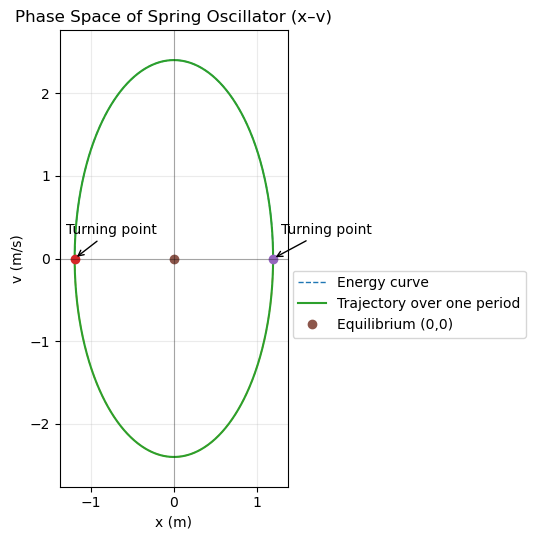

In [19]:
# Phase-space plot for the spring oscillator: (x, v)
# Shows the energy ellipse, turning points, and a parametric trajectory over one period.
# Legend moved outside the plot area.

import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parameters (edit freely)
# -----------------------
m = 1.0       # mass (kg)
k = 4.0       # spring constant (N/m)
A = 1.2       # amplitude (m)

# Derived quantities
omega = np.sqrt(k/m)
T = 2 * np.pi / omega

# Parametric trajectory over one period
t = np.linspace(0, T, 800)
x_traj = A * np.cos(omega * t)
v_traj = -A * omega * np.sin(omega * t)

# Energy ellipse boundary from E = (1/2) k A^2  =>  v^2/(omega^2 A^2) + x^2/A^2 = 1
x_ellipse = np.linspace(-A, A, 600)
v_ellipse_plus  =  omega * np.sqrt(np.maximum(0.0, A**2 - x_ellipse**2))
v_ellipse_minus = -omega * np.sqrt(np.maximum(0.0, A**2 - x_ellipse**2))

# Turning points and equilibrium
turning_points = [(-A, 0.0), (A, 0.0)]
equilibrium = (0.0, 0.0)

# -----------------------
# Plotting
# -----------------------
fig, ax = plt.subplots(figsize=(7, 5.5))

# Energy ellipse (constant E curve)
ax.plot(x_ellipse, v_ellipse_plus,  linewidth=1, linestyle="--", label="Energy curve")
ax.plot(x_ellipse, v_ellipse_minus, linewidth=1, linestyle="--")

# Trajectory over one period (overlays the ellipse)
ax.plot(x_traj, v_traj, label="Trajectory over one period")

# Mark turning points and equilibrium
for (xt, vt) in turning_points:
    ax.plot(xt, vt, "o")
    ax.annotate("Turning point", xy=(xt, vt), xytext=(xt + 0.1*np.sign(xt), vt + 0.3),
                arrowprops=dict(arrowstyle="->", lw=1), fontsize=10)
ax.plot(*equilibrium, "o", label="Equilibrium (0,0)")

# Axes helpers
ax.axhline(0, color="k", linewidth=0.8, alpha=0.3)
ax.axvline(0, color="k", linewidth=0.8, alpha=0.3)

# Labels and aesthetics
ax.set_xlabel("x (m)")
ax.set_ylabel("v (m/s)")
ax.set_title("Phase Space of Spring Oscillator (x–v)")
ax.grid(True, alpha=0.25)

# Equal aspect for a true ellipse
ax.set_aspect("equal", adjustable="box")

# Adjust limits with padding
xpad = 0.15 * A
vmax = omega * A
vpad = 0.15 * vmax
ax.set_xlim(-A - xpad, A + xpad)
ax.set_ylim(-vmax - vpad, vmax + vpad)

# Legend outside the plot
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.4), borderaxespad=0)

# Adjust layout to make room for the external legend
plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.show()

<div style="background-color:#d9d9d9; padding:15px; border-radius:10px;">
    
**Interpretation of the Phase Space Plot**

The **phase space plot** displays the oscillator’s state in terms of **position ($x$)** and **velocity ($v$)** rather than energy versus position.  
Each point on the curve represents a specific state of motion — that is, where the mass is and how fast it is moving at a given instant.

For a simple harmonic oscillator, the trajectory forms a **perfect ellipse** described by the equation  

$$
\frac{v^2}{(\omega A)^2} + \frac{x^2}{A^2} = 1,
$$

which comes directly from the conservation of energy,  

$$
E = \tfrac{1}{2}kA^2 = \tfrac{1}{2}k x^2 + \tfrac{1}{2}m v^2.
$$

---

**Key Features of the Plot**

- **Elliptical Shape:**  
  The ellipse represents all combinations of $x$ and $v$ that correspond to the same total energy $E$.  
  Every point on the ellipse satisfies energy conservation — as $x$ increases, $v$ must decrease, and vice versa.

- **Turning Points:**  
  The intersections with the $x$-axis ($x = \pm A$, $v = 0$) mark the **turning points**, where the kinetic energy is zero and potential energy is maximal.

- **Equilibrium Point:**  
  The origin ($x=0$, $v=0$) is the **equilibrium** — the point of minimum potential energy.  
  The trajectory passes through this point with the **maximum velocity**, when all the energy is kinetic.

- **Direction of Motion:**  
  As time evolves, the state moves smoothly around the ellipse in a counterclockwise or clockwise loop depending on the initial conditions.  
  The system cycles through all energy exchanges in one period $T = 2\pi/\omega$.

---

**Physical Interpretation**

The phase space view provides a powerful, compact picture of the oscillator’s dynamics:
- It unites both **position** and **momentum (or velocity)** into a single geometric description.
- The **closed elliptical orbit** signifies **periodic motion** and **energy conservation**.
- The **size of the ellipse** grows with the system’s energy — larger amplitude means higher velocity extremes and a larger phase-space loop.

In systems with friction, these ellipses would gradually **spiral inward** (energy loss), while in driven systems, new **limit cycles** or more complex trajectories may appear.  
Thus, the phase-space representation forms the foundation for understanding not only simple oscillations but also more complex and chaotic dynamical systems.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B12.4.7 Beyond the Harmonic Approximation

For small displacements, the quadratic term dominates and motion is harmonic.  
But when displacements grow large, the neglected higher-order terms in the Taylor series become important:

$$
U(x) = U(x_0) + \tfrac{1}{2}k_{\text{eff}}(x - x_0)^2 + \tfrac{1}{3!}\alpha(x - x_0)^3 + \tfrac{1}{4!}\beta(x - x_0)^4 + \cdots
$$

These nonlinear terms cause **anharmonicity** — oscillations whose frequency depends on amplitude — and can lead to complex phenomena such as **bifurcations**, **resonances**, and even **chaotic motion**.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B12.4.8 Broader Implications

The same stability framework extends far beyond simple mechanical systems:

- In **engineering**, it predicts the onset of failure or oscillation in mechanical and electrical systems.  
- In **chemistry**, potential energy surfaces determine reaction stability and transition states.  
- In **biology**, stable equilibria correspond to homeostasis, while unstable ones describe critical thresholds or tipping points in biological systems.  
- In **astrophysics**, the gravitational potential explains the difference between circular, elliptical, and unbound orbits.  
- And in **nonlinear dynamics**, studying small perturbations around equilibrium gives insight into how systems transition from regular to **chaotic behavior**.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B12.4.9 Summary

> Whenever the potential energy curve has a **local minimum**, small perturbations lead to **stable, oscillatory motion** (SHM).  
> A **maximum** leads to **instability**, and a **flat** potential gives **neutral equilibrium**.  
>  
> These simple principles — derived from the shape of $U(x)$ — form the foundation for understanding stability, oscillations, and chaos across all of science and engineering.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">